In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/df_final_experiment_clients.csv", sep=";")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


,client_id
count,7.060900e+04
mean,5.004992e+06
std,2.877278e+06
min,1.690000e+02
25%,2.519329e+06
50%,5.016978e+06
75%,7.483085e+06
max,9.999839e+06


In [10]:
import pandas as pd

# 1. Load the file correctly
df = pd.read_csv("../data/raw/df_final_experiment_clients.csv", sep=";")

# 2. Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 3. Quick checks
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types before cleaning:")
print(df.dtypes)

print("\nMissing values before cleaning:")
print(df.isna().sum())

print("\nDuplicate rows before cleaning:", df.duplicated().sum())

print("\nUnique values in variation before cleaning:")
print(df["variation"].value_counts(dropna=False))


# 4. Fix column types
df["client_id"] = pd.to_numeric(df["client_id"], errors="coerce").astype("Int64")

# 5. Standardize categories
df["variation"] = df["variation"].astype("string").str.strip().str.title()

# 6. Handle missing values
# Here we keep missing values as "Missing" so you don't lose rows
df["variation"] = df["variation"].fillna("Missing")

# 7. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# 8. Final checks
print("\nData types after cleaning:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isna().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nUnique values in variation after cleaning:")
print(df["variation"].value_counts(dropna=False))

print("\nCleaned head:")
print(df.head())

# 9. Save cleaned file
df.to_csv("df_final_experiment_clients_clean.csv", index=False)

Shape: (70609, 2)

Columns:
Index(['client_id', 'variation'], dtype='object')

Data types before cleaning:
client_id     int64
variation    object
dtype: object

Missing values before cleaning:
client_id        0
variation    20109
dtype: int64

Duplicate rows before cleaning: 0

Unique values in variation before cleaning:
variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

Data types after cleaning:
client_id             Int64
variation    string[python]
dtype: object

Missing values after cleaning:
client_id    0
variation    0
dtype: int64

Duplicate rows after cleaning: 0

Unique values in variation after cleaning:
variation
Test       26968
Control    23532
Missing    20109
Name: count, dtype: Int64

Cleaned head:
   client_id variation
0    9988021      Test
1    8320017      Test
2    4033851   Control
3    1982004      Test
4    9294070   Control


In [11]:
print("""
Cleaning summary:
- The file had to be loaded with ';' as separator.
- Column names were standardized to lowercase snake_case.
- client_id was converted to numeric.
- variation values were standardized.
- Missing values in variation were filled with 'Missing'.
- Duplicate rows were checked and removed if present.
- The cleaned dataframe was saved as df_final_experiment_clients_clean.csv.
""")


Cleaning summary:
- The file had to be loaded with ';' as separator.
- Column names were standardized to lowercase snake_case.
- client_id was converted to numeric.
- variation values were standardized.
- Missing values in variation were filled with 'Missing'.
- Duplicate rows were checked and removed if present.
- The cleaned dataframe was saved as df_final_experiment_clients_clean.csv.



In [12]:
df['variation'].value_counts(normalize=True)

variation
Test       0.381934
Control    0.333272
Missing    0.284794
Name: proportion, dtype: Float64

In [13]:
df.to_csv("df_final_experiment_clients_clean.csv", index=False)

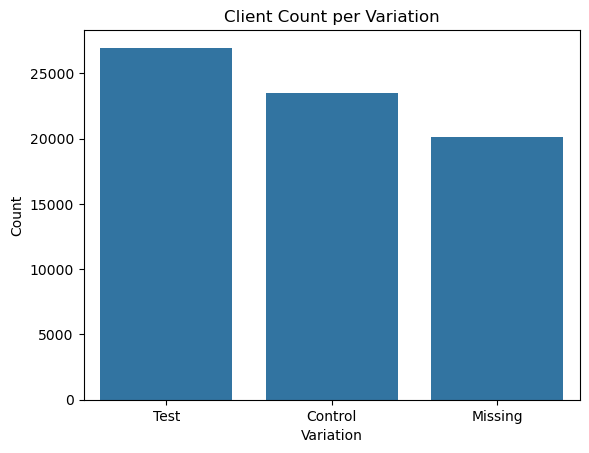

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="variation")

plt.title("Client Count per Variation")
plt.xlabel("Variation")
plt.ylabel("Count")

plt.show()

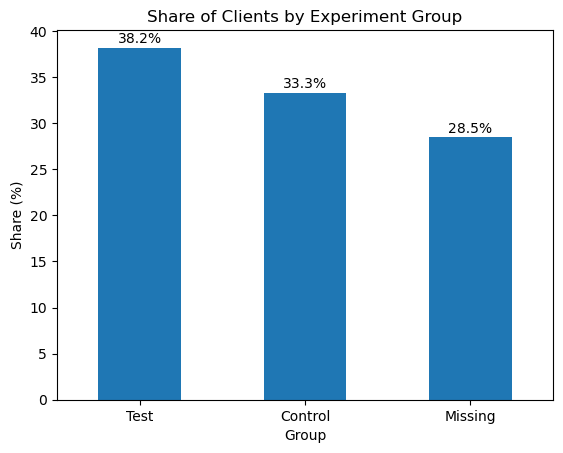

In [17]:
import matplotlib.pyplot as plt

# Calculate proportions
proportions = df['variation'].value_counts(normalize=True) * 100

# Plot
proportions.plot(kind='bar')

plt.title("Share of Clients by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Share (%)")
plt.xticks(rotation=0)

# Add percentage labels
for i, v in enumerate(proportions):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

In [18]:
# Keep only real experiment participants
df_experiment = df[df['variation'].isin(['Test', 'Control'])]

df_experiment['variation'].value_counts()

variation
Test       26968
Control    23532
Name: count, dtype: Int64

/var/folders/b7/yg62l3k53kvc1lvmnwswr23m0000gn/T/ipykernel_92163/2927504496.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, counts[i] + 200, f"{v:.1f}%", ha='center')


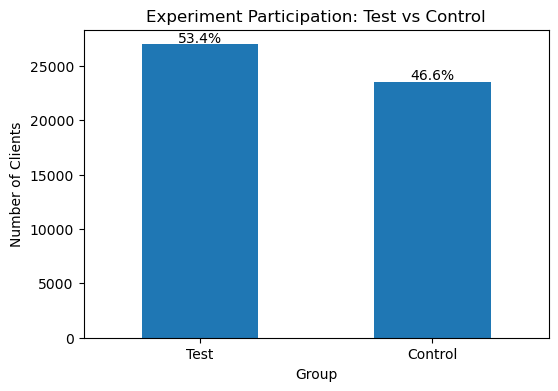

In [19]:
import matplotlib.pyplot as plt

counts = df_experiment['variation'].value_counts()
percentages = df_experiment['variation'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.title("Experiment Participation: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)

for i, v in enumerate(percentages):
    plt.text(i, counts[i] + 200, f"{v:.1f}%", ha='center')

plt.show()

Interpretation

The distribution of clients across experiment variations shows that 38.2% of users were assigned to the Test group, 33.3% to the Control group, and 28.5% have no recorded variation and are labeled as Missing. Ideally, in an A/B test, participants are evenly split between Test and Control groups to ensure fair comparisons. In this dataset, the Test group is slightly larger than the Control group, though the difference is not substantial. The presence of a large Missing category (28.5%) suggests that a significant portion of clients were either not included in the experiment or were not properly assigned to a variation in this dataset. For the purpose of evaluating the experiment’s effectiveness, the analysis should focus only on the Test and Control groups, since only those users were exposed to either the new interface or the original one. Excluding the Missing group will allow a clearer comparison of user behavior and completion rates between the two experimental conditions.
